<a href="https://colab.research.google.com/github/vlhsilvia/TRABAJOS-PRACTICOS/blob/Silviamaster/Copia_de_Geotaller5__An%C3%A1lisis_de_Proximidad.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Geotaller: Análisis de Proximidad: Qué tan lejos está tu punto de interés?

**Objetivo del Geotaller**

Capacitar a los participantes en el cálculo de distancias geográficas y proximidad de puntos de interés usando Python y herramientas open source.

Al final del taller, los asistentes serán capaces de:

* ✅ Calcular distancias geográficas entre un punto de referencia y los paraderos del SITP.
* ✅ Determinar los paraderos más cercanos a una ubicación específica.
* ✅ Visualizar los resultados en un mapa interactivo con Folium.



## 1. Introducción
🔹 Presentación del Problema

📍 **¿Por qué calcular proximidad en este contexto es importante?**

El acceso al transporte público es un factor crucial en la calidad de vida urbana. La distancia que las personas deben caminar hasta un paradero puede determinar:

- El tiempo total de viaje diario
- La probabilidad de usar el transporte público
- La accesibilidad a oportunidades laborales y educativas
- La equidad en la movilidad urbana

📍 **Caso de Uso**:

Usaremos un dataset con paraderos zonales del SITP en Bogotá y analizaremos qué tan lejos están de un punto de referencia, por ejemplo, la Plaza de Bolívar en Bogotá. [Podrás encontrar este dataset en la siguiente página:](https://datosabiertos-transmilenio.hub.arcgis.com/search?groupIds=69785fbaa2524cd88a47fe75c58ef48c)

📍 Herramientas que Usaremos:
- Python como lenguaje de programación
- Google Colab como entorno de desarrollo
- GeoPandas para análisis espacial
- Folium para visualización interactiva de mapas

## 2. Desarrollo Práctico (20-25 min)

💻 Cálculo de proximidad en 5 pasos simples

🔹 Paso 1: Carga y Exploración del GeoJSON|

In [ ]:
# Importación de librerías
import pandas as pd
import geopandas as gpd
import folium
from folium import plugins
import matplotlib.pyplot as plt

In [ ]:
# Cargar el archivo GeoJSON de paraderos SITP
path = "/content/Paraderos_Zonales_del_SITP.geojson"
paraderos = gpd.read_file(path)


In [ ]:
paraderos.tail()

,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry
7618,7619,681A08,08,Br. Galán,DG 2,DG 2 - KR 60,Puente Aranda,-74.123524,4.619313,681,S,DG 2 - KR 60 (681A08),DG 2 - KR 60,Diagonal 2 Carrera 60,F,{A584D50A-4B5B-4690-BBB5-651A609D5FA7},None,POINT (-74.12353 4.61932)
7619,7620,682A08,08,Parque TorreMolinos,KR 52,KR 52 - CL 18 Sur,Puente Aranda,-74.122032,4.608824,682,S,KR 52 - CL 18 Sur (682A08),KR 52 - CL 18 Sur,Carrera 52 Calle 18 Sur,G,{AB44F027-A2A9-4319-89F3-25F82B7EA746},None,POINT (-74.122 4.60883)
7620,7621,024B04,04,Ciudad Bachué,KR 95G,KR 95G - CL 89,Engativá,-74.103042,4.717693,024,M,KR 95G - CL 89 (024B04),KR 95G - CL 89,Carrera 95 G Calle 89,D,{0297BE18-5F54-49F8-A07C-C4DC07B23364},None,None
7621,7622,680A08,08,None,TV 64,TV 64 - CL 1,Puente Aranda,-74.124231,4.619924,680,None,None,None,Transversal 64 Calle 1,None,{C5756024-CB6B-447B-93F0-2C17177B369D},None,POINT (-74.12411 4.6199)
7622,7623,534C09,09,Br. San Bernardino XIX,KR 95 A,KR 95 A - CL 75A Sur,Bosa,-74.204501,4.630389,534,M,KR 95A - CL 75A Sur (534C09),KR 95A - CL 75A Sur,Carrera 95 A Calle 75 A Sur,G,{094D083E-22B2-430D-9496-1AB7908F0A82},None,None


In [ ]:
#Verificamos el sistema de coordenadas
paraderos.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [ ]:
#Usamos el método info
paraderos.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 7623 entries, 0 to 7622
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   objectid           7623 non-null   int32   
 1   cenefa             7623 non-null   object  
 2   zona_sitp          7623 non-null   object  
 3   nombre             7622 non-null   object  
 4   via                7623 non-null   object  
 5   direccion_bandera  7623 non-null   object  
 6   localidad          7623 non-null   object  
 7   longitud           7623 non-null   float64 
 8   latitud            7623 non-null   float64 
 9   consecutivo_zona   7623 non-null   object  
 10  tipo_m_s           7622 non-null   object  
 11  consola            7622 non-null   object  
 12  panel              7622 non-null   object  
 13  audio              7623 non-null   object  
 14  zonas_nuevas       7622 non-null   object  
 15  globalid           7623 non-null   object  
 16

In [ ]:
!pip install contextily
import contextily as cx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 26.8 MB/s eta 0:00:00


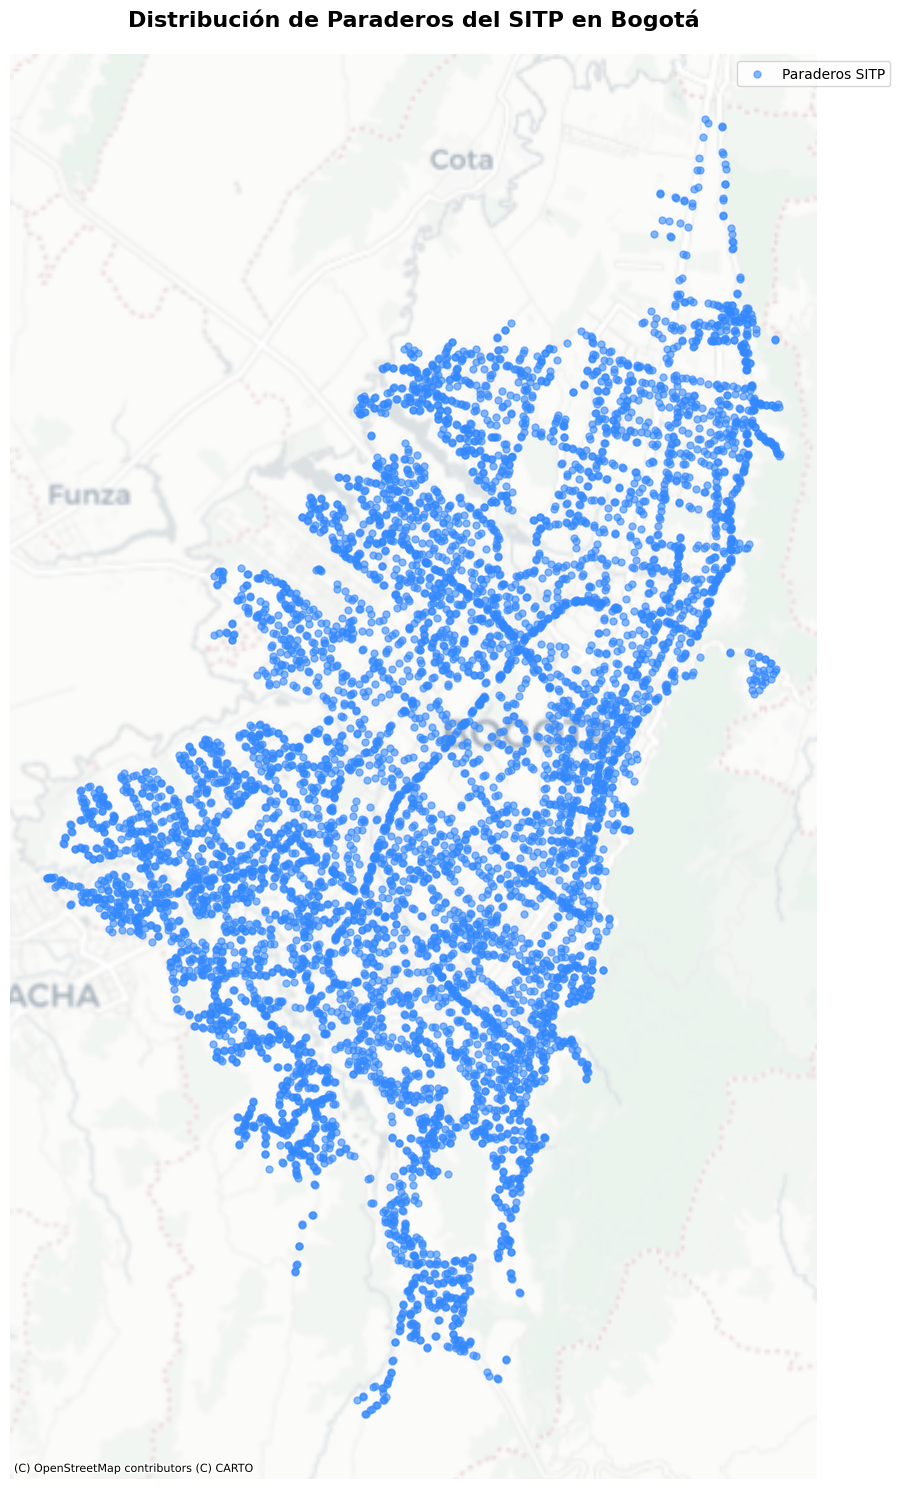

In [ ]:
#Podemos visualizarlo también en el espacio
fig, ax = plt.subplots(figsize=(15, 15))

# Plotear los paraderos con mejor estética
paraderos.plot(
    ax=ax,
    color='#3388ff',  # Azul más atractivo
    markersize=25,    # Tamaño de puntos más visible
    alpha=0.6,        # Transparencia para mejor visualización
    label='Paraderos SITP'
)

# Añadimos el mapa base con parámetros mejorados
cx.add_basemap(
    ax=ax,
    crs=paraderos.crs,
    source=cx.providers.CartoDB.Positron,  # Estilo de mapa más limpio
    alpha=0.8  # Transparencia del mapa base
)

# Mejoramos la apariencia del mapa
ax.set_title('Distribución de Paraderos del SITP en Bogotá',
             pad=20,
             fontsize=16,
             fontweight='bold')

# Añadimos una leyenda
ax.legend(loc='upper right',
         bbox_to_anchor=(1.1, 1),
         frameon=True)

# Eliminamos los ejes pero mantenemos el marco
ax.set_axis_off()

# Ajustamos los márgenes
plt.tight_layout()

# Mostramos el mapa
plt.show()

✅ Objetivos hasta ahora (checked):
|
1. Verificar que el dataset contiene columnas con coordenadas geográficas.

2. Confirmar que está en EPSG:4326 (WGS 84) para cálculos de distancia.

🔹 Paso 2: Limpieza y Preparación de Datos

In [ ]:
# Verificar si hay valores nulos en la geometría
paraderos['geometry'].isnull().sum()

2

In [ ]:
# Eliminar filas sin coordenadas
paraderos_notNull= paraderos.dropna(subset=['geometry'])

#Resteamos index
paraderos_notNull = paraderos_notNull.reset_index(drop=True)

In [ ]:
#Revisamos el número resultante de fila
paraderos_notNull.tail()

,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry
7616,7617,BD-065A,BD,Clínica El Bosque,AC 134,AC 134 - AK 7,Usaquén,-74.029964,4.711994,BD-,M,AC 134 - AK 7 (BD-065A),AC 134 - AK 7,Avenida Calle 134 Avenida Carrera Séptima,B,{7C9BD281-673D-49C9-BCBC-B5B5702A4D68},None,POINT (-74.02996 4.71199)
7617,7618,BD-066A,BD,Portal Usme,CL 67 D Sur,CL 67 D Sur - Av. Caracas,Usme,-74.118635,4.528868,BD-,M,CL 67 D Sur - Av. Caracas (BD-066A),CL 67 D Sur - Av. Caracas,Calle 67 D Sur Avenida Caracas,H,{B54276B8-4F11-4679-8C4A-75D2ABBD2BE1},None,POINT (-74.11863 4.52887)
7618,7619,681A08,08,Br. Galán,DG 2,DG 2 - KR 60,Puente Aranda,-74.123524,4.619313,681,S,DG 2 - KR 60 (681A08),DG 2 - KR 60,Diagonal 2 Carrera 60,F,{A584D50A-4B5B-4690-BBB5-651A609D5FA7},None,POINT (-74.12353 4.61932)
7619,7620,682A08,08,Parque TorreMolinos,KR 52,KR 52 - CL 18 Sur,Puente Aranda,-74.122032,4.608824,682,S,KR 52 - CL 18 Sur (682A08),KR 52 - CL 18 Sur,Carrera 52 Calle 18 Sur,G,{AB44F027-A2A9-4319-89F3-25F82B7EA746},None,POINT (-74.122 4.60883)
7620,7622,680A08,08,None,TV 64,TV 64 - CL 1,Puente Aranda,-74.124231,4.619924,680,None,None,None,Transversal 64 Calle 1,None,{C5756024-CB6B-447B-93F0-2C17177B369D},None,POINT (-74.12411 4.6199)


✅ Objetivos hasta ahora (checked):

Asegurar que los datos sean válidos y utilizables para el análisis de proximidad

🔹 Paso 3: Cálculo de Distancia desde un Punto de Referencia

**Con la información de la latitud y longitud del punto de referencia, vamos a crear dos elementos derivados a partir de este:**

1. Un objeto de tipo POINT de shapely: Con este vamos a crear el geodataFrame, y nos servirá principalmente para calcular las distancias con respecto a cada paradero
2. un geodataFrame: con fines de visualizar la información

[Enlace de Google Maps:](https://www.google.com/maps/place/Plaza+de+Bol%C3%ADvar/@4.6058343,-74.1959031,12.09z/data=!4m10!1m2!2m1!1splaza+bolivar!3m6!1s0x8e3f99a7eccfe58f:0x99cb72b35351476!8m2!3d4.5981206!4d-74.0760435!15sCg1wbGF6YSBib2xpdmFyWg8iDXBsYXphIGJvbGl2YXKSAQVwbGF6YeABAA!16zL20vMGMzcGt2?hl=es&entry=ttu&g_ep=EgoyMDI1MDMwNC4wIKXMDSoJLDEwMjExNDU1SAFQAw%3D%3D)

```
4.603263780841703, -74.07727594966315
```



**Creamos el objeto tipo POINT**

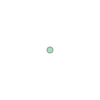

In [ ]:
from shapely.geometry import Point

# Definir punto de referencia (Plaza de Bolívar, Bogotá) en EPSG:4326 (Lat, Lon)
punto_referencia = Point(-74.07727594966315, 4.603263780841703)  # NOTA: Shapely usa (Lon, Lat)

punto_referencia

**Lo llevamos a geodataFrame**

In [ ]:
# Crear un GeoDataFrame con el punto de referencia
punto_referencia_gdf = gpd.GeoDataFrame([{"geometry": punto_referencia}], crs="EPSG:4326")

punto_referencia_gdf

,geometry
0,POINT (-74.07728 4.60326)


In [ ]:
#Le podemos poner el nombre del punto: creamos una neuva columna
punto_referencia_gdf['punto_referencia'] = 'Plaza Bolívar'

punto_referencia_gdf

,geometry,punto_referencia
0,POINT (-74.07728 4.60326),Plaza Bolívar


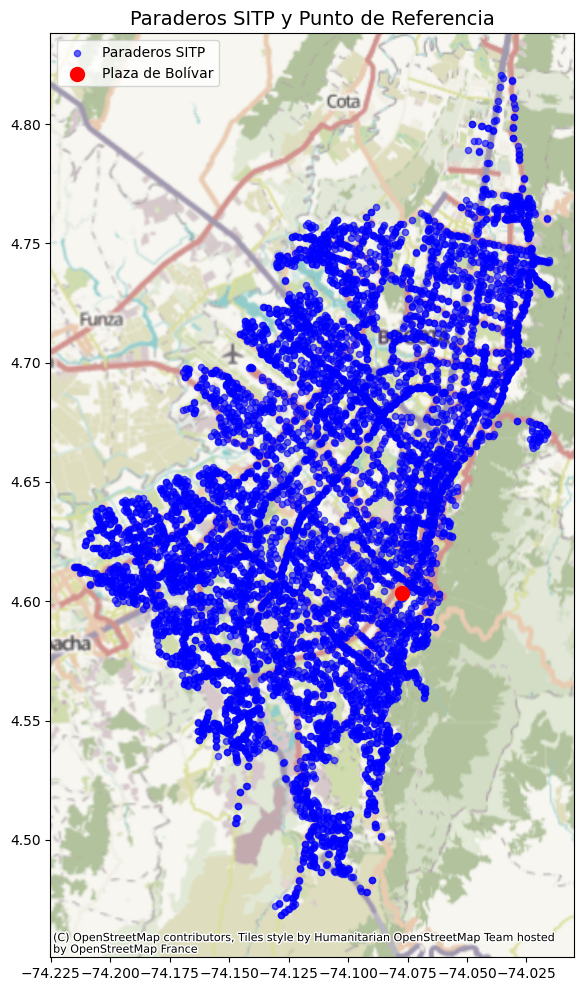

In [ ]:
# Creamos un mapa que muestra paraderos y punto de referencia
# 1. Configuramos el tamaño del mapa
fig, ax2 = plt.subplots(figsize=(12, 12))

# 2. Añadimos los elementos al mapa
# Paraderos en azul
paraderos_notNull.plot(
    ax=ax2,
    color='blue',
    alpha=0.6,               # Transparencia
    markersize=20,          # Tamaño de puntos
    label='Paraderos SITP'   # Etiqueta para la leyenda
)

# Punto de referencia en rojo
punto_referencia_gdf.plot(
    ax=ax2,
    color='red',
    markersize=100,         # Punto más grande para destacar
    label='Plaza de Bolívar' # Etiqueta para la leyenda
)

# 3. Añadimos el mapa base de OpenStreetMap
cx.add_basemap(ax=ax2, crs=paraderos_notNull.crs)

# 4. Mejoramos la presentación
ax2.set_title('Paraderos SITP y Punto de Referencia', fontsize=14)
ax2.legend()                 # Añadimos la leyenda

plt.show()

**Reproyectamos el geodataFrame de punto de interés al EPSG=9377**

In [ ]:
# Reproyectar el punto de referencia a EPSG:9377
punto_referencia_gdf_9377= punto_referencia_gdf.to_crs(epsg=9377)

punto_referencia_gdf_9377.tail()

,geometry,punto_referencia
0,POINT (4880551.079 2066745.994),Plaza Bolívar


**Extraemos la geometría del geodataFrame reproyectado de punto de interés:**

Este es clave porque nos servirá para calcular las distancais

In [ ]:
# Extraer las coordenadas reproyectadas
punto_referencia_9377 = punto_referencia_gdf_9377.geometry.iloc[0]
print(f"Coordenadas del punto de referencia en EPSG:9377: {punto_referencia_9377}")

Coordenadas del punto de referencia en EPSG:9377: POINT (4880551.079293362 2066745.9935023668)


**Reproyectar el GeoDataFrame de paraderos al CRS EPSG:9377**

In [ ]:
paraderos_notNull_9377 = paraderos_notNull.to_crs(epsg=9377)

paraderos_notNull_9377.tail()

,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry
7616,7617,BD-065A,BD,Clínica El Bosque,AC 134,AC 134 - AK 7,Usaquén,-74.029964,4.711994,BD-,M,AC 134 - AK 7 (BD-065A),AC 134 - AK 7,Avenida Calle 134 Avenida Carrera Séptima,B,{7C9BD281-673D-49C9-BCBC-B5B5702A4D68},None,POINT (4885815.156 2078754.127)
7617,7618,BD-066A,BD,Portal Usme,CL 67 D Sur,CL 67 D Sur - Av. Caracas,Usme,-74.118635,4.528868,BD-,M,CL 67 D Sur - Av. Caracas (BD-066A),CL 67 D Sur - Av. Caracas,Calle 67 D Sur Avenida Caracas,H,{B54276B8-4F11-4679-8C4A-75D2ABBD2BE1},None,POINT (4875951.817 2058531.289)
7618,7619,681A08,08,Br. Galán,DG 2,DG 2 - KR 60,Puente Aranda,-74.123524,4.619313,681,S,DG 2 - KR 60 (681A08),DG 2 - KR 60,Diagonal 2 Carrera 60,F,{A584D50A-4B5B-4690-BBB5-651A609D5FA7},None,POINT (4875424.223 2068527.836)
7619,7620,682A08,08,Parque TorreMolinos,KR 52,KR 52 - CL 18 Sur,Puente Aranda,-74.122032,4.608824,682,S,KR 52 - CL 18 Sur (682A08),KR 52 - CL 18 Sur,Carrera 52 Calle 18 Sur,G,{AB44F027-A2A9-4319-89F3-25F82B7EA746},None,POINT (4875591.955 2067368.738)
7620,7622,680A08,08,None,TV 64,TV 64 - CL 1,Puente Aranda,-74.124231,4.619924,680,None,None,None,Transversal 64 Calle 1,None,{C5756024-CB6B-447B-93F0-2C17177B369D},None,POINT (4875360.56 2068592.686)


**Ahora volvemos a visualizar los geodataFrames reproyectados:**

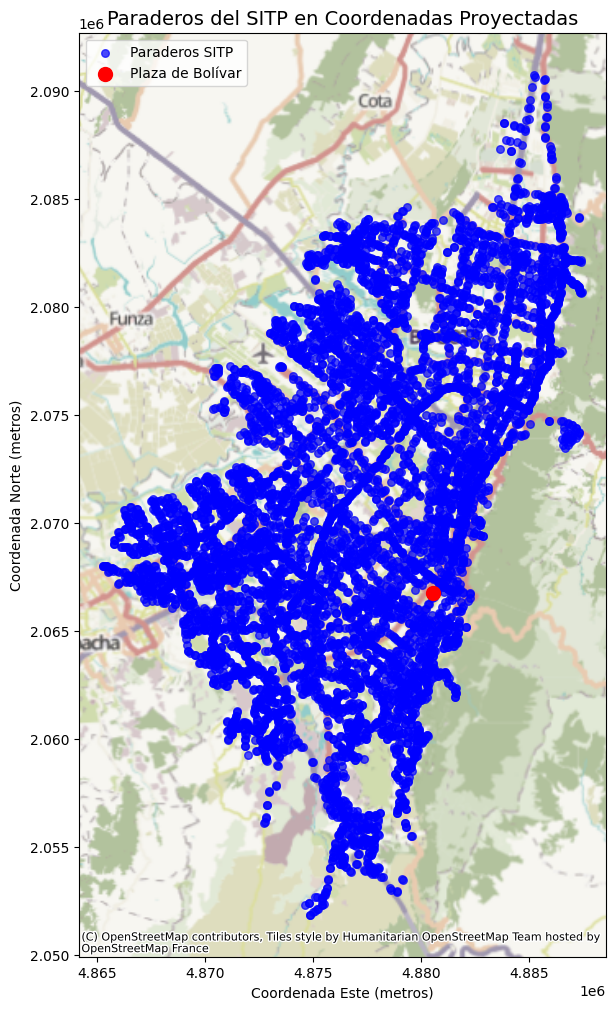

In [ ]:
# Creamos un mapa con los paraderos en proyección EPSG:9377
# Esta proyección nos permite trabajar con distancias en metros

# 1. Configuramos el mapa
fig, ax3 = plt.subplots(figsize=(12, 12))

# 2. Añadimos los paraderos al mapa
paraderos_notNull_9377.plot(
    ax=ax3,
    color='blue',
    alpha=0.7,                # Transparencia
    markersize=30,           # Tamaño de los puntos
    label='Paraderos SITP'    # Etiqueta para la leyenda
)

# 3. Añadimos el punto de referencia
punto_referencia_gdf_9377.plot(
    ax=ax3,
    color='red',
    markersize=100,          # Punto más grande para destacar
    label='Plaza de Bolívar'  # Etiqueta para la leyenda
)

# 4. Añadimos el mapa base
cx.add_basemap(ax=ax3, crs=paraderos_notNull_9377.crs)

# 5. Mejoramos la presentación del mapa
ax3.set_title('Paraderos del SITP en Coordenadas Proyectadas', fontsize=14)
ax3.set_xlabel('Coordenada Este (metros)')   # Eje X en metros
ax3.set_ylabel('Coordenada Norte (metros)')  # Eje Y en metros
ax3.legend()                                # Añadimos la leyenda

plt.show()

✅ Objetivo:

* Llevar tanto el geodataFrame de paraderos, así como también el punto de referencia al mismo sistema de coordenadas: checked

**Cálculo de Distancias usando Coordenadas Proyectadas**

In [ ]:
# Calcular distancia en metros desde el punto de referencia a cada paradero en EPSG:9377
paraderos_notNull_9377['distancia_m'] = paraderos_notNull_9377['geometry'].distance(punto_referencia_9377)

paraderos_notNull_9377.tail()


,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry,distancia_m
7616,7617,BD-065A,BD,Clínica El Bosque,AC 134,AC 134 - AK 7,Usaquén,-74.029964,4.711994,BD-,M,AC 134 - AK 7 (BD-065A),AC 134 - AK 7,Avenida Calle 134 Avenida Carrera Séptima,B,{7C9BD281-673D-49C9-BCBC-B5B5702A4D68},None,POINT (4885815.156 2078754.127),13111.283962
7617,7618,BD-066A,BD,Portal Usme,CL 67 D Sur,CL 67 D Sur - Av. Caracas,Usme,-74.118635,4.528868,BD-,M,CL 67 D Sur - Av. Caracas (BD-066A),CL 67 D Sur - Av. Caracas,Calle 67 D Sur Avenida Caracas,H,{B54276B8-4F11-4679-8C4A-75D2ABBD2BE1},None,POINT (4875951.817 2058531.289),9414.594169
7618,7619,681A08,08,Br. Galán,DG 2,DG 2 - KR 60,Puente Aranda,-74.123524,4.619313,681,S,DG 2 - KR 60 (681A08),DG 2 - KR 60,Diagonal 2 Carrera 60,F,{A584D50A-4B5B-4690-BBB5-651A609D5FA7},None,POINT (4875424.223 2068527.836),5427.671793
7619,7620,682A08,08,Parque TorreMolinos,KR 52,KR 52 - CL 18 Sur,Puente Aranda,-74.122032,4.608824,682,S,KR 52 - CL 18 Sur (682A08),KR 52 - CL 18 Sur,Carrera 52 Calle 18 Sur,G,{AB44F027-A2A9-4319-89F3-25F82B7EA746},None,POINT (4875591.955 2067368.738),4998.071885
7620,7622,680A08,08,None,TV 64,TV 64 - CL 1,Puente Aranda,-74.124231,4.619924,680,None,None,None,Transversal 64 Calle 1,None,{C5756024-CB6B-447B-93F0-2C17177B369D},None,POINT (4875360.56 2068592.686),5509.243296


**Los organizamos de acuerdo a sus valores de distancia**

In [ ]:
#Ordenemos el geodataFrame por distancias
paraderos_ordenado = paraderos_notNull_9377.sort_values(by='distancia_m', ascending=False)

#Reseteamos el index
paraderos_ordenado = paraderos_ordenado.reset_index(drop=True)

paraderos_ordenado.head()

,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry,distancia_m
0,4762,336A02,02,Bogotá Tenis Club Campestre,Auto Norte,Auto Norte - CL 242,Suba,-74.035576,4.820427,336,S,Auto Norte - CL 242 (336A02),Auto Norte - CL 242,Autopista Norte Calle 242,B,{5C84A45E-42A6-4A42-990D-5AB7375277E0},None,POINT (4885210.907 2090738.074),24440.415574
1,7287,661A01,01,Br. Torca Góngora,Auto Norte,Auto Norte - CL 242,Usaquén,-74.034800,4.819357,661,S,Auto Norte - CL 242 (661A01),Auto Norte - CL 242,Autopista Norte Calle 242,B,{9A6875FF-6490-4803-A662-B8F76B56E556},None,POINT (4885296.788 2090619.737),24340.858014
2,6840,582A01,01,Torca Rural I,AK 7,AK 7 - CL 245,Usaquén,-74.030974,4.818458,582,S,AK 7 - CL 245 (582A01),AK 7 - CL 245,Avenida Carrera Séptima Calle 245,B,{62F83912-4DAB-4BF7-9B2D-564BD2E7D3F3},None,POINT (4885720.743 2090519.7),24329.293556
3,6846,583A01,01,Torca Rural I,AK 7,AK 7 - CL 245,Usaquén,-74.031017,4.818156,583,S,AK 7 - CL 245 (583A01),AK 7 - CL 245,Avenida Carrera Séptima Calle 245,B,{6CE21C0E-5652-41C9-A845-76F1B7FC19B8},None,POINT (4885715.964 2090486.403),24295.742349
4,4770,337A02,02,Planta de Concreto,Auto Norte,Auto Norte . CL 238,Suba,-74.036252,4.815460,337,S,Auto Norte . CL 238 (337A02),Auto Norte . CL 238,Autopista Norte Calle 238,B,{C2C91CA2-2D35-412E-A5AF-2A1B1B7928CE},None,POINT (4885135.206 2090189.368),23887.361001


**Exportamos los resultados a un archvo en formato Geojson**

In [ ]:
# Exportar los resultados a GeoJSON
paraderos_ordenado.to_file("paraderos_ordenados.geojson", driver="GeoJSON")

✅ Objetivo:

Guardar los datos en un formato estándar para GIS (Checked)

🔹 Paso 4: Visualización en un Mapa Interactivo

In [ ]:
import folium

# Crear el mapa centrado en Bogotá
m = folium.Map(location=[4.5981, -74.0758], zoom_start=12)

m

In [ ]:
# Agregar marcador del punto de referencia
folium.Marker(location=[4.5981, -74.0758], popup="Plaza de Bolívar", icon=folium.Icon(color="red")).add_to(m)

m

**Paremos aquí:**

Siempre que querramos agregar información espacial a Folium, debemos asegurarnos de que esta esté en formato geojson. En el caso de los geodataFrames, la manera en que nos cersioramos de esto es que estén en un sistema de coordenadas geográficas

In [ ]:
def reproyectar_geodataFrame(gdf, crs):
    gdf_reproyected = gdf.to_crs(epsg=crs)
    return gdf_reproyected

In [ ]:
paraderos_ordenado_reproyected_4326 = reproyectar_geodataFrame(paraderos_ordenado, 4326)

paraderos_ordenado_reproyected_4326.head()

,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry,distancia_m
0,4762,336A02,02,Bogotá Tenis Club Campestre,Auto Norte,Auto Norte - CL 242,Suba,-74.035576,4.820427,336,S,Auto Norte - CL 242 (336A02),Auto Norte - CL 242,Autopista Norte Calle 242,B,{5C84A45E-42A6-4A42-990D-5AB7375277E0},None,POINT (-74.03558 4.82043),24440.415574
1,7287,661A01,01,Br. Torca Góngora,Auto Norte,Auto Norte - CL 242,Usaquén,-74.034800,4.819357,661,S,Auto Norte - CL 242 (661A01),Auto Norte - CL 242,Autopista Norte Calle 242,B,{9A6875FF-6490-4803-A662-B8F76B56E556},None,POINT (-74.0348 4.81936),24340.858014
2,6840,582A01,01,Torca Rural I,AK 7,AK 7 - CL 245,Usaquén,-74.030974,4.818458,582,S,AK 7 - CL 245 (582A01),AK 7 - CL 245,Avenida Carrera Séptima Calle 245,B,{62F83912-4DAB-4BF7-9B2D-564BD2E7D3F3},None,POINT (-74.03097 4.81846),24329.293556
3,6846,583A01,01,Torca Rural I,AK 7,AK 7 - CL 245,Usaquén,-74.031017,4.818156,583,S,AK 7 - CL 245 (583A01),AK 7 - CL 245,Avenida Carrera Séptima Calle 245,B,{6CE21C0E-5652-41C9-A845-76F1B7FC19B8},None,POINT (-74.03102 4.81816),24295.742349
4,4770,337A02,02,Planta de Concreto,Auto Norte,Auto Norte . CL 238,Suba,-74.036252,4.815460,337,S,Auto Norte . CL 238 (337A02),Auto Norte . CL 238,Autopista Norte Calle 238,B,{C2C91CA2-2D35-412E-A5AF-2A1B1B7928CE},None,POINT (-74.03625 4.81546),23887.361001


**Pero digamos que quisiéramos agregar únicamente las 20 paraderos más cercanos del SITP**

Observemos que hay muchísimos registros. Seleccionemos únicamente aquellos cuyos valores de distancia al punto de referencia-La Plaza Bolívar- hace parte del grupo de las 10 menores

In [ ]:
paraderos_ordenado_reproyected_4326_20Cercanos = paraderos_ordenado_reproyected_4326.tail(20)

#Resteamos index
paraderos_ordenado_reproyected_4326_20Cercanos.reset_index(drop=True, inplace=True)

In [ ]:
paraderos_ordenado_reproyected_4326_20Cercanos

,objectid,cenefa,zona_sitp,nombre,via,direccion_bandera,localidad,longitud,latitud,consecutivo_zona,tipo_m_s,consola,panel,audio,zonas_nuevas,globalid,shape,geometry,distancia_m
0,3671,244B00,00,Pl. Las Nieves,AC 19,AC 19 - KR 7,Santa Fe,-74.071940,4.605692,244,M,AC 19 - KR 7 (244B00),AC 19 - KR 7,Avenida Calle 19 Carrera Séptima,A,{308F6304-42D9-4CFE-B3E8-F512955B7B3C},None,POINT (-74.07194 4.60569),649.710726
1,7483,811A00,00,Br. La Alameda,AK 10,AK 10 - AC 19,Santa Fe,-74.073519,4.607712,811,S,AK 10 - AC 19 (811A00),AK 10 - AC 19,Avenida Carrera Décima Avenida Calle 19,A,{DF499C84-1C92-4BAE-B9A6-AF5D54C5EDAC},None,POINT (-74.07352 4.60771),644.364649
2,6060,469A00,00,Instituto Técnico Central de Bogotá,KR 17,KR 17 - CL 13,Los Mártires,-74.081873,4.606652,469,S,KR 17 - CL 13 (469A00),KR 17 - CL 13,Carrera 17 Calle 13,A,{28111C99-4AEB-4F9E-907E-CFC41036EEFD},None,POINT (-74.08187 4.60665),632.515853
3,3658,244A00,00,Pl. Las Nieves,AC 19,AC 19 - KR 9,Santa Fe,-74.072660,4.606151,244,M,AC 19 - KR 9 (244A00),AC 19 - KR 9,Avenida Calle 19 Carrera Novena,A,{0476B6C6-4E48-4FF1-A8EB-97D66698F53B},None,POINT (-74.07266 4.60615),603.152652
4,3643,243A00,00,Br. Veracruz,AC 19,AC 19 - KR 8,Santa Fe,-74.072638,4.605835,243,M,AC 19 - KR 8 (243A00),AC 19 - KR 8,Avenida Calle 19 Carrera Octava,A,{27E4A358-21EF-4234-B16E-4960EF94DD62},None,POINT (-74.07264 4.60584),587.651330
5,3725,249A00,00,Br. La Alameda,AC 19,AC 19 - AK 13,Santa Fe,-74.074856,4.607786,249,M,AC 19 - AK 13 (249A00),AC 19 - AK 13,Avenida Calle 19 Avenida Carrera 13,A,{DA716772-D9D1-4571-94DC-4B62283A7B99},None,POINT (-74.07486 4.60779),567.252600
6,3632,241B00,00,Br. La Capuchina,AC 19,AC 19 - AK 13,Santa Fe,-74.075670,4.608085,241,M,AC 19 - AK 13 (241B00),AC 19 - AK 13,Avenida Calle 19 Avenida Carrera 13,A,{F898C3C5-0E52-4AE2-8654-3E7E0478C3C7},None,POINT (-74.07567 4.60808),561.769412
7,3737,249B00,00,Br. La Alameda,AC 19,AC 19 - KR 12,Santa Fe,-74.074612,4.607587,249,M,AC 19 - KR 12 (249B00),AC 19 - KR 12,Avenida Calle 19 Carrera 12,A,{561A9EEB-D5D5-40CE-AD76-017E46F2E48C},None,POINT (-74.07461 4.60759),561.754545
8,7456,785A00,00,Br. Centro Administrativo,AK 10,AK 10 - CL 9,Candelaria,-74.078755,4.598561,785,S,AK 10 - CL 9 (785A00),AK 10 - CL 9,Avenida Carrera Décima Calle Novena,A,{FACCA46D-D446-42FD-9179-BC82DC5F9580},None,POINT (-74.07875 4.59856),544.997124
9,3656,243B00,00,Br. Veracruz,AC 19,AC 19 - KR 8,Santa Fe,-74.073512,4.606434,243,M,AC 19 - KR 8 (243B00),AC 19 - KR 8,Avenida Calle 19 Carrera Octava,A,{23B770EA-1B77-4EE6-BB96-3863D5DD27CD},None,POINT (-74.07351 4.60643),544.963749


In [ ]:
# Agregar los 10 paraderos más cercanos
for _, row in paraderos_ordenado_reproyected_4326_20Cercanos.iterrows():
    folium.Marker(
        location=[row.geometry.y, row.geometry.x],
        popup=f"Paradero (Distancia: {round(row.distancia_m, 2)} km)"
    ).add_to(m)

# Mostrar el mapa
m